In [102]:
#  Inputs
line_label = 'NeVIII' #'NeVIII', 'SiII', 'CIV', or 'cold_line'

eit_wavelength = 195 #171, 195, 284, or 304 [Angstrom]
eit_time = 'late' #'early' or 'late' (early: around 1 or 4 am; late: around 6 or 7 am)

# Threshold value: label (type) and range of percentageRange percentage of the threshold value
threshold_value_type_sumer = 'mean' #'max', 'min', 'mean', 'median'
range_percentage_sumer = [0., 37.6]
threshold_value_type_eit = 'mean' #'max', 'min', 'mean', 'median'
percentage_contour_eit = 90.

# Wavelength ranges to crop spectra
wavelength_range_to_average = [1531.1147, 1551.7688]
wavelength_range_to_analyze_NeVIII = [1540.2, 1541.4]

# save average profile as .npy?
save_average_profile_map = 'no' 


####################################
# subtraction of HRTS

sun_region = 'qqr_a' #HRTS spectrum

fwhm_conv = 1.95*0.04215 #nm

color_sumer = 'blue'
color_hrts = 'green'
color_sumer_uncorrected = 'red'
color_sumer_corrected = 'blue'

## Ranges of wavelength
wavelength_range_scalefactor_left = [1537.7, 1539.5] #nm
wavelength_range_scalefactor_right = [1542., 1544.] #nm

In [103]:
######################################################
# Initial parameters of the fitting

bckg_fit_uncorrected = 0.2 #HRST not subtracted
init_parameters_uncorrected = [bckg_fit_uncorrected, #[background, amplitude1, mean1, FWHM1, amplitude2, mean2, FWHM2,...]
           0.3-bckg_fit_uncorrected, -54., 20.,
           1.07-bckg_fit_uncorrected, -10, 45.,
           0.5-bckg_fit_uncorrected, 15., 45.,
           0.25-bckg_fit_uncorrected, 97., 30.
           ]

if sun_region=='qqr_a':
    wavelength_range_NeVIII = [1540.32, 1541.43]
    bckg_fit_corrected = -0.3
    init_parameters_corrected = [bckg_fit_corrected, #[background, amplitude1, mean1, FWHM1, amplitude2, mean2, FWHM2,...]
                   0.1-bckg_fit_corrected, -60., 20.,
                   0.5-bckg_fit_corrected, -30., 20.,
                   3.-bckg_fit_corrected, 0.0, 50.,
                   #1.5-bckg_fit_corrected, 25., 30.
                   ]
               
elif sun_region=='qqr_b':
    wavelength_range_NeVIII = [1540.3, 1541.43]
    bckg_fit_corrected = 0.0
    init_parameters_corrected = [bckg_fit_corrected, #[background, amplitude1, mean1, FWHM1, amplitude2, mean2, FWHM2,...]
                   0.04-bckg_fit_corrected, -78., 30.,
                   0.3-bckg_fit_corrected, -50., 30.,
                   0.5-bckg_fit_corrected, -30., 40.,
                   0.8-bckg_fit_corrected, 0.0, 50.,
                   #1.5-bckg_fit_corrected, 33., 40.
                   ]
                   
elif sun_region=='qqr_l':
    bckg_fit_corrected = 0.
    init_parameters_corrected = [bckg_fit_corrected, #[background, amplitude1, mean1, FWHM1, amplitude2, mean2, FWHM2,...]
                   0.08-bckg_fit_corrected, -75., 20.,
                   0.3-bckg_fit_corrected, -35., 30.,
                   0.8-bckg_fit_corrected, 7., 50.,
                   0.022-bckg_fit_corrected, 77., 30.
                   ]

In [104]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import datetime as dt
from astropy.io import fits
import matplotlib.patches as patches
from scipy.odr import Model, RealData, ODR
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import sunpy.map
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
import astropy.units as u
from matplotlib.path import Path
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d


import sys
import os
sys.path.append(os.path.abspath('..'))
from utils.data_path import path_data_soho 
from utils.SOHO_aux_functions import *
from utils.calibration_parameters__output import *
from utils.spectroheliogram_functions import *
from utils.solar_rotation_variables import *
from utils.aux_functions import *
from utils.general_variables import *
from utils.NeVIII_rest_wavelength import *


In [105]:
## Rest wavelength used
rest_wavelength_label = 'Peter_and_Judge_1999' #'SUMER_atlas', 'Peter_1998', 'Dammasch_1999', 'Peter_and_Judge_1999', 'Kelly_database'
lam_0 = 2.*NeVIII_theoretical_wavelength_dic[rest_wavelength_label][0] #Angstrom
lam_unc_0 = 2.*NeVIII_theoretical_wavelength_dic[rest_wavelength_label][1] #Angstrom
print('Rest wavelength Ne VIII (2nd order):', lam_0, r'$\pm$', lam_unc_0, '\u212B')

Rest wavelength Ne VIII (2nd order): 1540.856 $\pm$ 0.014 Å


In [106]:
# Load the intensity map and uncertainties
intensitymap_loaded_dic = np.load('../outputs/intensity_map_'+line_label+'_interpolated.npz')
intensity_map = intensitymap_loaded_dic['intensity_map'] #2D-array
intensity_map_unc = intensitymap_loaded_dic['intensity_map_unc'] #2D-array
line_center_label = intensitymap_loaded_dic['line_center_label'] 
vmin_sumer, vmax_sumer = intensitymap_loaded_dic['vmin_vmax'] 

# Crop array in latitude 
intensity_map_croplat = intensity_map[slit_top_px:slit_bottom_px+1,:]
intensity_map_unc_croplat = intensity_map_unc[slit_top_px:slit_bottom_px+1,:]


In [107]:
# Import SUMER data interpolated (wavelength calibrated)
data_interpolated_loaded = np.load('../data/data_modified/wcal4__spectral_image_list_intepolated_and_wavelength.npz', allow_pickle=True)
spectral_image_interpolated_list = data_interpolated_loaded['spectral_image_interpolated_list']
spectral_image_unc_interpolated_list = data_interpolated_loaded['spectral_image_unc_interpolated_list']
lam_sumer = data_interpolated_loaded['reference_wavelength']          # scalar (0‑d array; use a_loaded.item() for Python float)
lam_sumer_unc = data_interpolated_loaded['unc_reference_wavelength'] #uncertainty of lam_sumer
row_reference = int(data_interpolated_loaded['row_reference'])        # becomes a NumPy array or object array, so I conver it to integer again


Observatory,Solar and Heliospheric Observatory (SOHO)
Instrument,Extreme-ultraviolet Imaging Telescope (EIT)
Detector,EIT
Measurement,195.0 Angstrom
Wavelength,195.0 Angstrom
Observation Date,1999-11-07 06:36:24
Exposure Time,4.597 s
Dimension,[512. 512.] pix
Coordinate System,helioprojective
Scale,[5.254 5.254] arcsec / pix
Reference Pixel,[255.5 255.5] pix

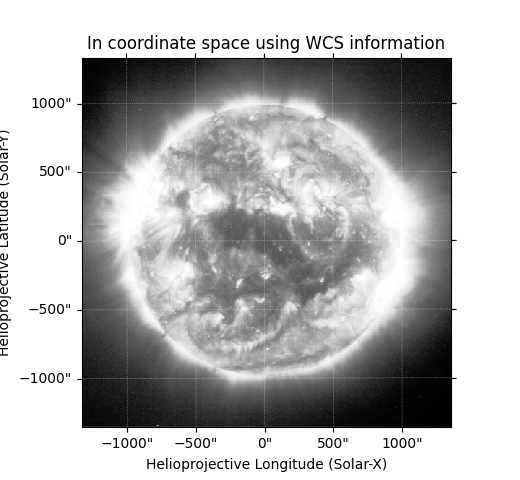
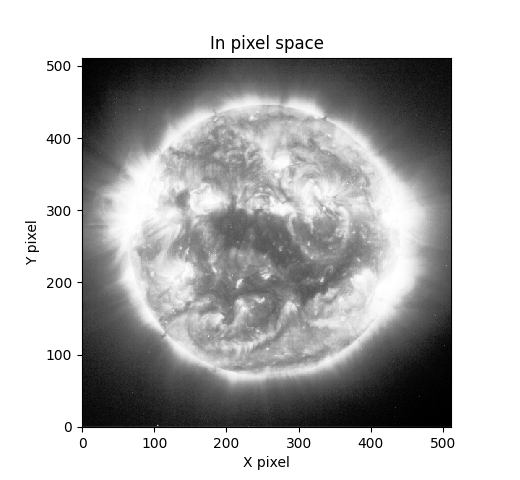
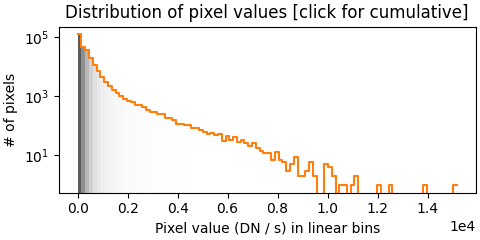
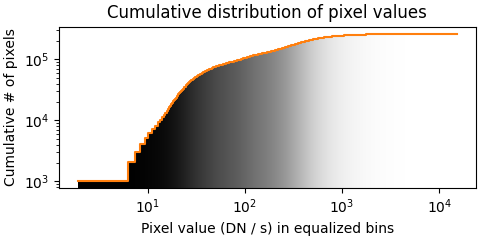

In [108]:
# Import EIT data

# Select the name of the EIT file according to the above inputs
if eit_time=='early':
    if eit_wavelength==171: 
        filename_eit = 'SOHO_EIT_171_19991107T010032_L1.fits'
        vmin_eit, vmax_eit = 3e1, 3e2
    elif eit_wavelength==195: 
        filename_eit = 'SOHO_EIT_195_19991107T042103_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==284: 
        filename_eit = 'SOHO_EIT_284_19991107T011231_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==304: 
        filename_eit = 'SOHO_EIT_304_19991107T013601_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3

elif eit_time=='late':
    if eit_wavelength==171: 
        filename_eit = 'SOHO_EIT_171_19991107T070017_L1.fits'
        vmin_eit, vmax_eit = 3e1, 3e2
    elif eit_wavelength==195: 
        filename_eit = 'SOHO_EIT_195_19991107T063706_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==284: 
        filename_eit = 'SOHO_EIT_284_19991107T070704_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3
    elif eit_wavelength==304: 
        filename_eit = 'SOHO_EIT_304_19991107T073030_L1.fits'
        vmin_eit, vmax_eit = 4e1, 3e3

# Path of EIT file
filepath_eit = path_data_soho + 'eit/' + filename_eit

# Extract data and header
data_eit = fits.getdata(filepath_eit)[::-1]
header_eit = fits.getheader(filepath_eit)

# Creating a SunPy map object from an image
map_eit = sunpy.map.Map(filepath_eit)
map_eit

In [109]:
from auxiliar_functions.solar_rotation_variables import *
closest_index = closest_index_EIT_SUMER_dic[filename_eit]
closest_time_sumer = closest_time_SUMER_to_EIT_dic[filename_eit]
time_eit = time_EIT_dic[filename_eit]
hour_eit = hour_EIT_dic[filename_eit]
HPlon_rotcomp = HPlon_rotcomp_dic[filename_eit]
HPlon
HPlat
HPlat_croplat = HPlat[slit_top_px:slit_bottom_px+1]


# HP latitude of the top and bottom limits of the SUMER spectra
HPlat_crop_top = HPlat[slit_top_px]
HPlat_crop_bottom = HPlat[slit_bottom_px]


## Find row index in EIT corresponding to these limits
y_px_crop_top = int(np.round(Y__HP_to_pixel(y_HP=HPlat_crop_top, header_eit=header_eit)))
y_px_crop_bottom = int(np.round(Y__HP_to_pixel(y_HP=HPlat_crop_bottom, header_eit=header_eit)))
x_px_crop_left = int(np.round(X__HP_to_pixel(x_HP=HPlon_rotcomp[0], header_eit=header_eit)))
x_px_crop_right = int(np.round(X__HP_to_pixel(x_HP=HPlon_rotcomp[-1], header_eit=header_eit)))


# Crop EIT array
data_eit_crop = data_eit[y_px_crop_top:y_px_crop_bottom, x_px_crop_left:x_px_crop_right]

# Corrected alignment
dx_px = 0
dy_px = -6
data_eit_crop_corrected = data_eit[y_px_crop_top+dy_px : y_px_crop_bottom+dy_px, x_px_crop_left+dx_px : x_px_crop_right+dx_px]


eit_extent = sumer_extent = [HPlon_rotcomp[0], HPlon_rotcomp[-1], HPlat_croplat[-1], HPlat_croplat[0]]


# Define extents properly for EACH image
extent_eit_px = [-0.5, data_eit_crop_corrected.shape[1]-0.5, data_eit_crop_corrected.shape[0]-0.5, -0.5]
extent_sumer_px = [-0.5, intensity_map_croplat.shape[1]-0.5, intensity_map_croplat.shape[0]-0.5, -0.5]

In [110]:
arr_sumer = intensity_map_croplat
arr_eit = data_eit_crop_corrected


In [111]:
lower_bound_sumer, upper_bound_sumer = get_bounds(intensitymap_croplat=arr_sumer, range_percentage=range_percentage_sumer, threshold_value_type=threshold_value_type_sumer)
print('lower_bound_sumer, upper_bound_sumer =', lower_bound_sumer, ',', upper_bound_sumer)

rowscols_inside_range_sumer_for_plot = range_intensity_addresses_of_SUMER_spectroheliogram(intensitymap_croplat=arr_sumer, lower_bound=lower_bound_sumer, upper_bound=upper_bound_sumer, slit_top_px=slit_top_px)
rowscols_inside_range_sumer_for_data = []
for y_row, x_col in rowscols_inside_range_sumer_for_plot: rowscols_inside_range_sumer_for_data.append((y_row+slit_top_px, x_col))
print('Number of pixels detected in SUMER:', len(rowscols_inside_range_sumer_for_plot))


lower_bound_sumer, upper_bound_sumer = 0.0 , 0.16409476399167133
Number of pixels detected in SUMER: 5614


In [112]:
range_percentage_eit = [percentage_contour_eit, 1.1*np.max(arr_eit)*100./np.mean(arr_eit)]
lower_bound_eit, upper_bound_eit = get_bounds(intensitymap_croplat=arr_eit, range_percentage=range_percentage_eit, threshold_value_type=threshold_value_type_eit)
print('lower_bound_eit, upper_bound_eit =', lower_bound_eit, ',', upper_bound_eit)

rowscols_inside_range_eit = range_intensity_addresses_of_SUMER_spectroheliogram(intensitymap_croplat=arr_eit, lower_bound=lower_bound_eit, upper_bound=upper_bound_eit, slit_top_px=0)
print('Number of pixels detected in EIT:', len(rowscols_inside_range_eit))

rows_cols_sumer_from_eit_for_plot = map_pixels_array1_to_array2(arr1=arr_eit, arr2=arr_sumer, pixel_address_list_1=rowscols_inside_range_eit)
rows_cols_sumer_from_eit_for_data = []
for y_row, x_col in rows_cols_sumer_from_eit_for_plot: rows_cols_sumer_from_eit_for_data.append((y_row+slit_top_px, x_col))
print('Number of pixels in SUMER:', len(rows_cols_sumer_from_eit_for_plot))

lower_bound_eit, upper_bound_eit = 170.08305 , 3646.112
Number of pixels detected in EIT: 2554
Number of pixels in SUMER: 28134


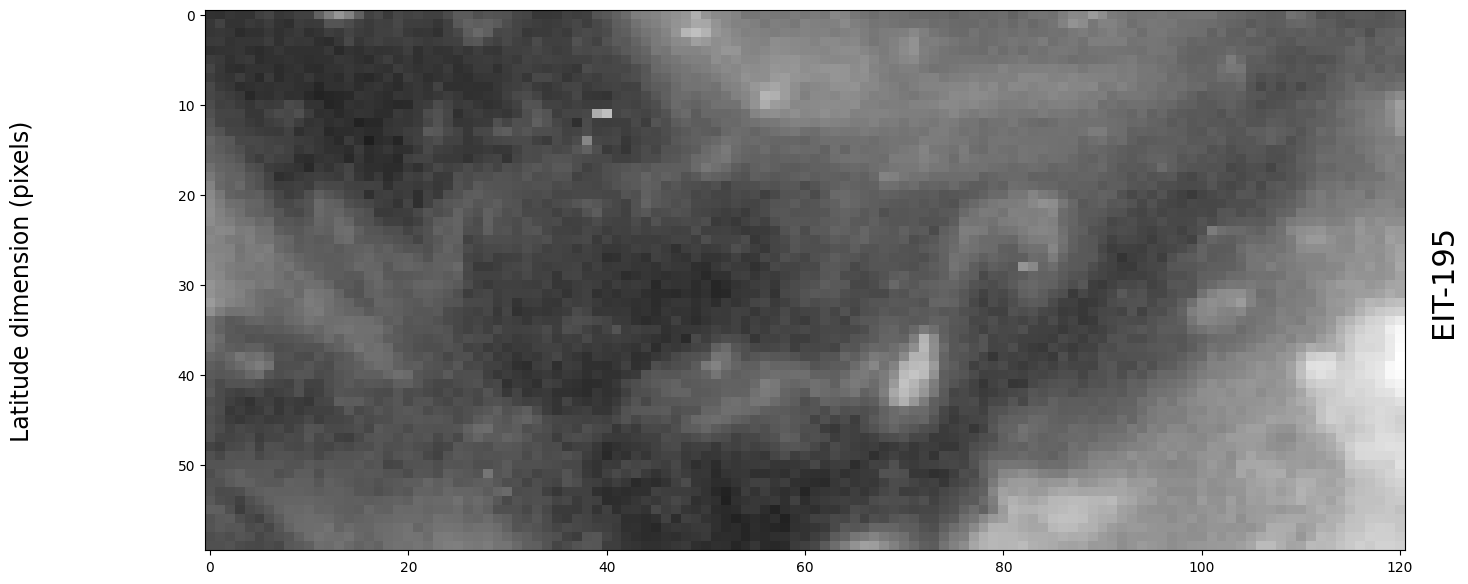

In [113]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15,6))
label_size = 18
ax.imshow(arr_eit, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', aspect='auto')
fig.supylabel('Latitude dimension (pixels)', fontsize=17)
ax.text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax.transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0.1)
plt.show(block=False)

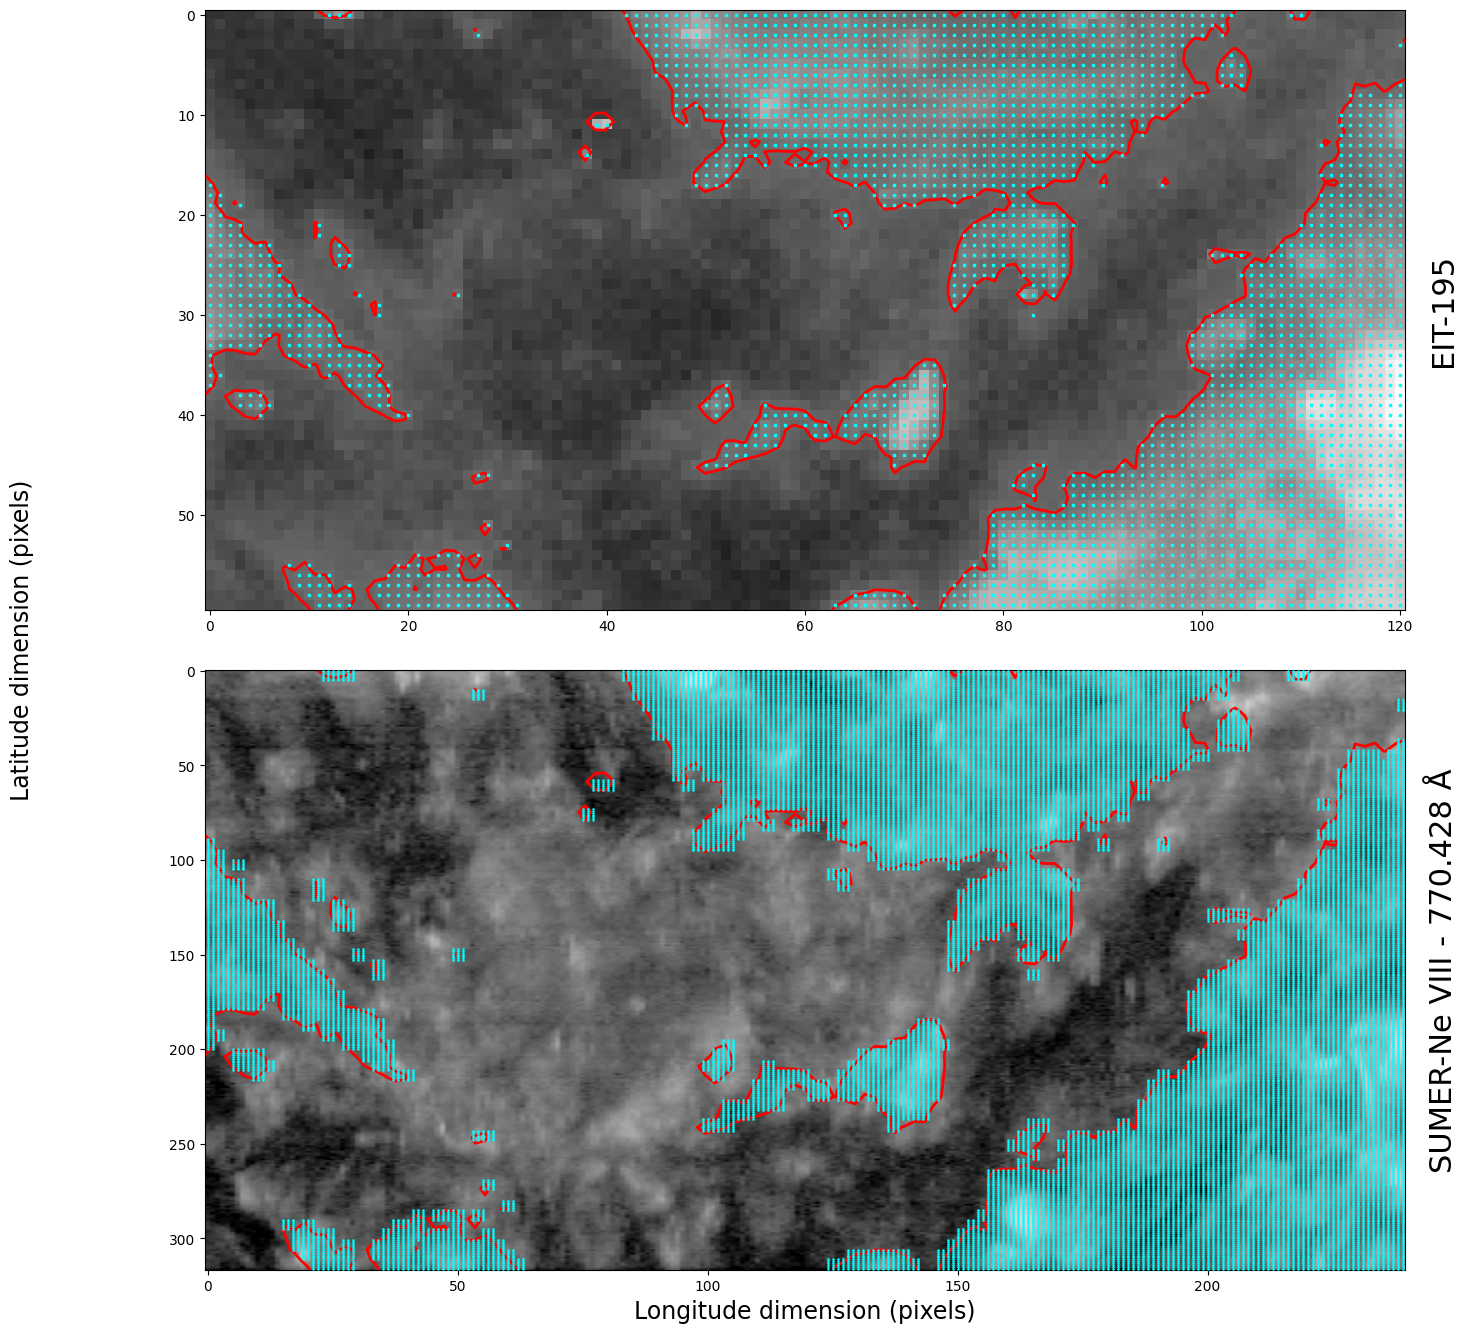

In [114]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,14))
label_size = 18
ax[0].imshow(arr_eit, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', aspect='auto')
ax[1].imshow(arr_sumer, norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), cmap='Greys_r', aspect='auto')
ax[1].set_aspect('auto')

ax[1].set_xlabel('Longitude dimension (pixels)', fontsize=17)
fig.supylabel('Latitude dimension (pixels)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0.1)



# EIT subplot (top) - contours from EIT data
contour_lower_eit = ax[0].contour(arr_eit[::-1], levels=[lower_bound_eit], colors='red', linewidths=2, extent=extent_eit_px)
contour_upper_eit = ax[0].contour(arr_eit[::-1], levels=[upper_bound_eit], colors='blue', linewidths=2, extent=extent_eit_px)
# EIT subplot (bottom) - contours from EIT data
contour_lower_eit = ax[1].contour(arr_eit[::-1], levels=[lower_bound_eit], colors='red', linewidths=2, extent=extent_sumer_px)
contour_upper_eit = ax[1].contour(arr_eit[::-1], levels=[upper_bound_eit], colors='blue', linewidths=2, extent=extent_sumer_px)


# Scatter points - FLIP Y to match contour orientation
x_col1_list, y_row1_list_flipped = [], []
for y_row1, x_col1 in rowscols_inside_range_eit:
    x_col1_list.append(x_col1)
    #y_row1_list_flipped.append(data_eit_crop_corrected.shape[0] - 1 - y_row1)  # Flip Y
    y_row1_list_flipped.append(y_row1)  # Flip Y

x_col2_list, y_row2_list_flipped = [], []
for y_row2, x_col2 in rows_cols_sumer_from_eit_for_plot:
    x_col2_list.append(x_col2)
    #y_row2_list_flipped.append(arr_sumer.shape[0] - 1 - y_row2)  # Flip Y
    y_row2_list_flipped.append(y_row2)  # Flip Y

# Plot scatter AFTER contours with zorder to ensure visibility
ax[0].scatter(x_col1_list, y_row1_list_flipped, color='cyan', marker='s', s=1, zorder=10)
ax[1].scatter(x_col2_list, y_row2_list_flipped, color='cyan', marker='o', s=0.7, zorder=10)

"""
ax[0].set_xlim([x_col1-5,x_col1+5])
ax[0].set_ylim([y_row1+2,y_row1-2])
ax[1].set_xlim([100,110])
ax[1].set_ylim([y_row1*dy+10,y_row1*dy-10])
"""

plt.show(block=False)

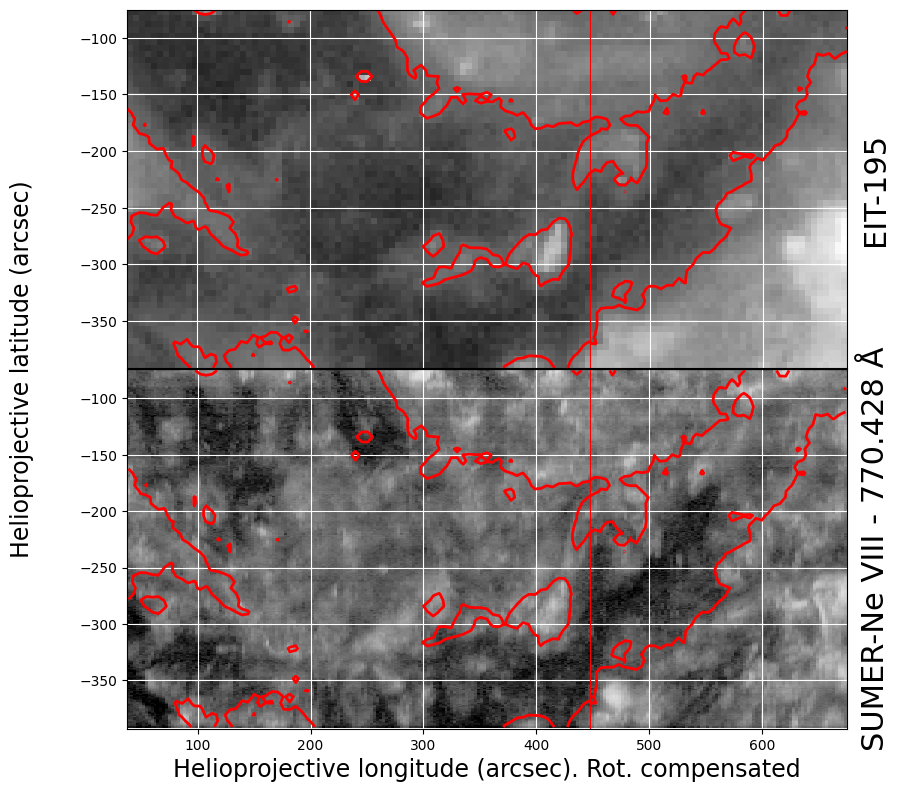

In [115]:
extent_eit_sumer = [HPlon_rotcomp[0], HPlon_rotcomp[-1], HPlat_croplat[-1], HPlat_croplat[0]]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(arr_eit, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', extent=eit_extent)
ax[1].pcolormesh(HPlon_rotcomp, HPlat_croplat, arr_sumer, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
ax[1].axis('equal') # Ensures equal scaling of axis x and y
#ax[1].set_title(f'SUMER', fontsize=22)
#ax[0].set_title(f'EIT-{header_eit["WAVELNTH"]}', fontsize=22)
ax[1].set_xlabel('Helioprojective longitude (arcsec). Rot. compensated', fontsize=17)
fig.supylabel('Helioprojective latitude (arcsec)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0)
ax[0].grid(color='white')
ax[1].grid(color='white')
ax[0].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
ax[1].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
#ax[0].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
#ax[1].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
contour_lower = ax[0].contour(arr_eit[::-1], levels=[lower_bound_eit], colors='red', linewidths=2, extent=extent_eit_sumer)
contour_upper = ax[0].contour(arr_eit[::-1], levels=[upper_bound_eit], colors='blue', linewidths=2, extent=extent_eit_sumer)

legend_elements = [
    mlines.Line2D([],[],color='red', label=f'{range_percentage_eit[0]} %'),
    mlines.Line2D([],[],color='blue', label=f'{range_percentage_eit[1]} %')
]

contour_lower = ax[1].contour(arr_eit[::-1], levels=[lower_bound_eit], colors='red', linewidths=2, extent=extent_eit_sumer)
contour_upper = ax[1].contour(arr_eit[::-1], levels=[upper_bound_eit], colors='blue', linewidths=2, extent=extent_eit_sumer)

plt.show(block=False)

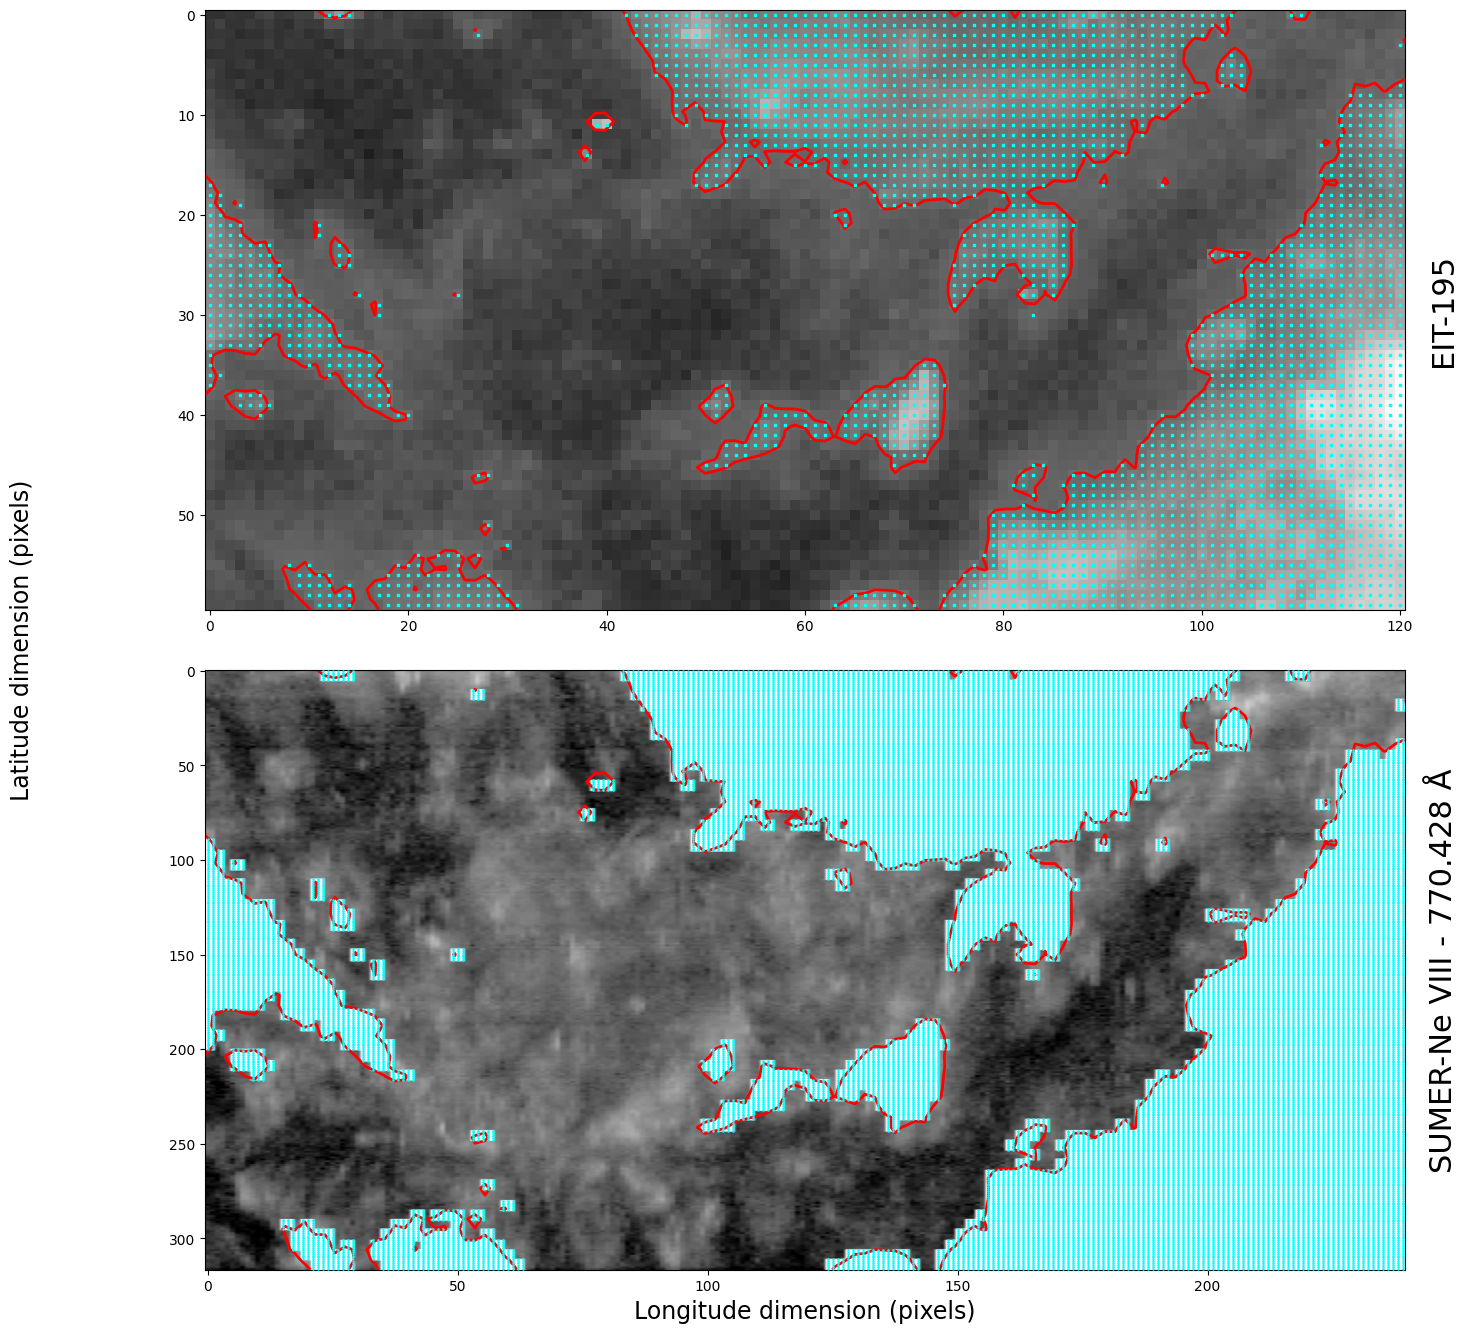

In [116]:

# Mask arr_sumer
mask_sumer = np.zeros(arr_sumer.shape, dtype=bool)
for y_row2, x_col2 in rows_cols_sumer_from_eit_for_plot:
    mask_sumer[y_row2, x_col2] = True
arr_sumer_CH = np.ma.masked_where(mask_sumer, arr_sumer) #coronal hole contours of EIT image


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,14))
label_size = 18
ax[0].imshow(arr_eit, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', aspect='auto')
ax[1].imshow(arr_sumer_CH, norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), cmap='Greys_r', aspect='auto')
ax[1].set_aspect('auto')

ax[1].set_xlabel('Longitude dimension (pixels)', fontsize=17)
fig.supylabel('Latitude dimension (pixels)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0.1)


# Define extents properly for EACH image
extent_eit_px = [-0.5, arr_eit.shape[1]-0.5, arr_eit.shape[0]-0.5, -0.5]
extent_sumer_px = [-0.5, arr_sumer.shape[1]-0.5, arr_sumer.shape[0]-0.5, -0.5]

# EIT subplot (top) - contours from EIT data
contour_lower_eit = ax[0].contour(arr_eit[::-1], levels=[lower_bound_eit], colors='red', linewidths=2, extent=extent_eit_px)
contour_upper_eit = ax[0].contour(arr_eit[::-1], levels=[upper_bound_eit], colors='blue', linewidths=2, extent=extent_eit_px)
# EIT subplot (bottom) - contours from EIT data
contour_lower_eit = ax[1].contour(arr_eit[::-1], levels=[lower_bound_eit], colors='red', linewidths=2, extent=extent_sumer_px)
contour_upper_eit = ax[1].contour(arr_eit[::-1], levels=[upper_bound_eit], colors='blue', linewidths=2, extent=extent_sumer_px)


# Scatter points - FLIP Y to match contour orientation
x_col1_list, y_row1_list_flipped = [], []
for y_row1, x_col1 in rowscols_inside_range_eit:
    x_col1_list.append(x_col1)
    #y_row1_list_flipped.append(data_eit_crop_corrected.shape[0] - 1 - y_row1)  # Flip Y
    y_row1_list_flipped.append(y_row1)  # Flip Y

x_col2_list, y_row2_list_flipped = [], []
for y_row2, x_col2 in rows_cols_sumer_from_eit_for_plot:
    x_col2_list.append(x_col2)
    #y_row2_list_flipped.append(arr_sumer.shape[0] - 1 - y_row2)  # Flip Y
    y_row2_list_flipped.append(y_row2)  # Flip Y

# Plot scatter AFTER contours with zorder to ensure visibility
ax[0].scatter(x_col1_list, y_row1_list_flipped, color='cyan', marker='s', s=1, zorder=10)
ax[1].scatter(x_col2_list, y_row2_list_flipped, color='cyan', marker='o', s=0.7, zorder=10)

"""
ax[0].set_xlim([x_col1-5,x_col1+5])
ax[0].set_ylim([y_row1+2,y_row1-2])
ax[1].set_xlim([100,110])
ax[1].set_ylim([y_row1*dy+10,y_row1*dy-10])
"""

plt.show(block=False)

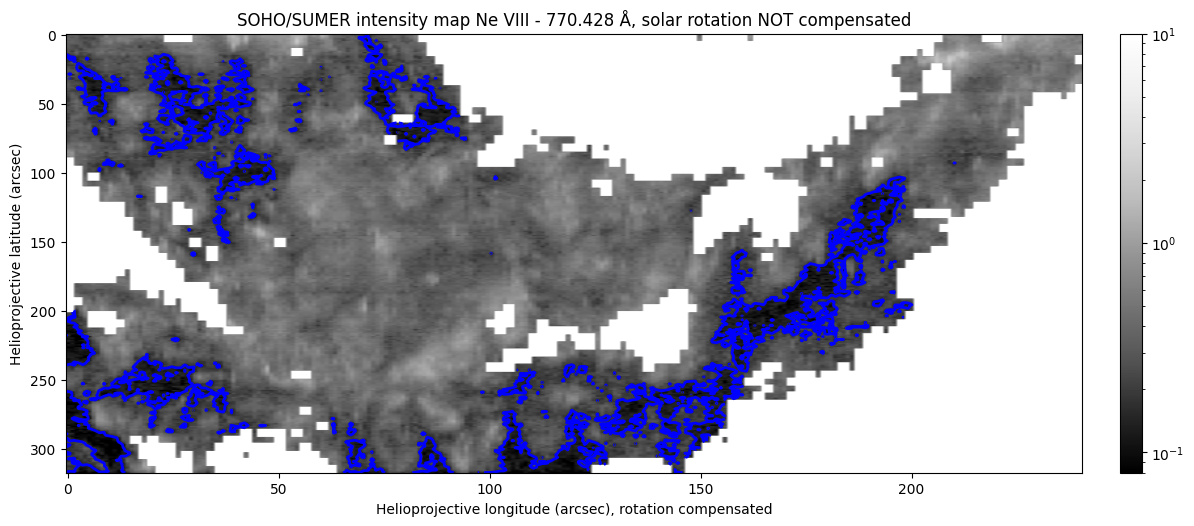

In [117]:
extent_ = [-0.5, arr_sumer.shape[1]+0.5, arr_sumer.shape[0]+0.5, -0.5]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5.7))
img = ax.imshow(arr_sumer_CH, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), extent=extent_)
cbar = fig.colorbar(img, ax=ax, pad=0.03)
ax.set_title(f'SOHO/SUMER intensity map {line_center_label}, solar rotation NOT compensated')
ax.set_xlabel('Helioprojective longitude (arcsec), rotation compensated')
ax.set_ylabel('Helioprojective latitude (arcsec)')
ax.axis('auto') # Ensures equal scaling of axis x and y
contour_lower = ax.contour(arr_sumer_CH[::-1], levels=[lower_bound_sumer], colors='red', linewidths=2, extent=extent_)
contour_upper = ax.contour(arr_sumer_CH[::-1], levels=[upper_bound_sumer], colors='blue', linewidths=2, extent=extent_)
legend_elements = [
    mlines.Line2D([],[],color='red', label=f'{lower_bound_sumer}'),
    mlines.Line2D([],[],color='blue', label=f'{upper_bound_sumer}')]
plt.show(block=False)

In [118]:
rowscols_inside_range_sumer_CH_for_plot = range_intensity_addresses_of_SUMER_spectroheliogram(intensitymap_croplat=arr_sumer_CH, lower_bound=lower_bound_sumer, upper_bound=upper_bound_sumer, slit_top_px=0)
rowscols_inside_range_sumer_CH_for_data = []
for y_row, x_col in rowscols_inside_range_sumer_CH_for_plot: rowscols_inside_range_sumer_CH_for_data.append((y_row+slit_top_px, x_col))
print('Number of pixels detected in SUMER:          ', len(rowscols_inside_range_sumer_for_plot))
print('Number of pixels detected in SUMER inside CH:', len(rowscols_inside_range_sumer_CH_for_plot))


Number of pixels detected in SUMER:           5614
Number of pixels detected in SUMER inside CH: 5456


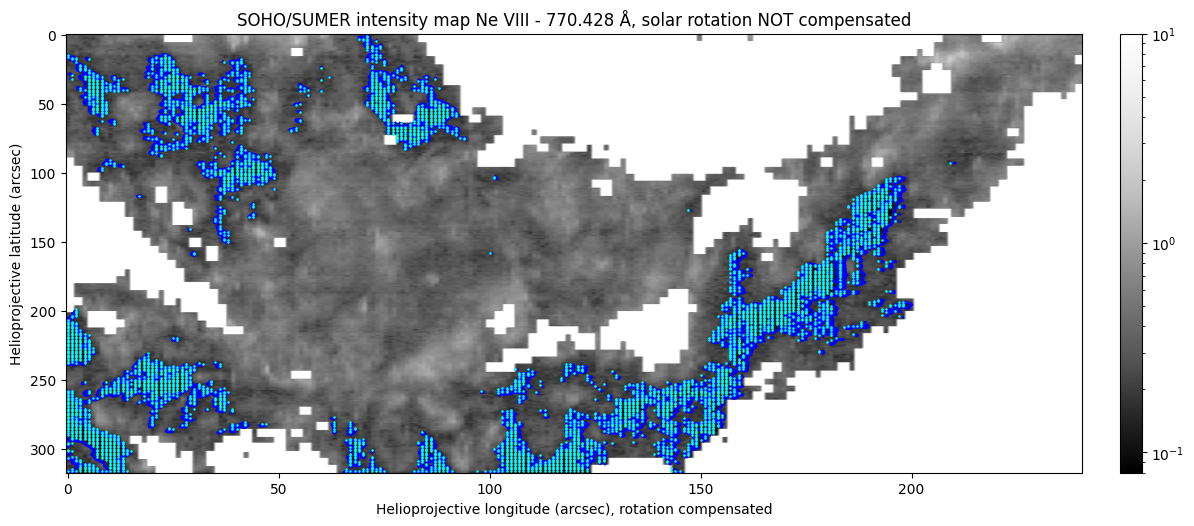

In [119]:
extent_ = [-0.5, arr_sumer.shape[1]+0.5, arr_sumer.shape[0]+0.5, -0.5]


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5.7))
img = ax.imshow(arr_sumer_CH, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), extent=extent_)
cbar = fig.colorbar(img, ax=ax, pad=0.03)
ax.set_title(f'SOHO/SUMER intensity map {line_center_label}, solar rotation NOT compensated')
ax.set_xlabel('Helioprojective longitude (arcsec), rotation compensated')
ax.set_ylabel('Helioprojective latitude (arcsec)')
ax.axis('auto') # Ensures equal scaling of axis x and y
contour_lower = ax.contour(arr_sumer_CH[::-1], levels=[lower_bound_sumer], colors='red', linewidths=2, extent=extent_)
contour_upper = ax.contour(arr_sumer_CH[::-1], levels=[upper_bound_sumer], colors='blue', linewidths=2, extent=extent_)
legend_elements = [
    mlines.Line2D([],[],color='red', label=f'{lower_bound_sumer}'),
    mlines.Line2D([],[],color='blue', label=f'{upper_bound_sumer}')]
x_col2_list, y_row2_list_flipped = [], []
for y_row2, x_col2 in rowscols_inside_range_sumer_CH_for_plot:
    x_col2_list.append(x_col2)
    #y_row2_list_flipped.append(arr_sumer.shape[0] - 1 - y_row2)  # Flip Y
    y_row2_list_flipped.append(y_row2)  # Flip Y
# Plot scatter AFTER contours with zorder to ensure visibility
ax.scatter(x_col2_list, y_row2_list_flipped, color='cyan', marker='o', s=0.7, zorder=10)

plt.show(block=False)

In [120]:
# Average spectra of the pixels selected
lam_sumer_av, rad_sumer_av, erad_sumer_av = average_profiles_from_pixels_selected_from_interpolated_data(wavelength_range_=wavelength_range_to_average, data_interpolated_loaded_=data_interpolated_loaded, rows_cols_of_spectroheliogram=rowscols_inside_range_sumer_CH_for_data)
lam_sumer, rad_sumer, erad_sumer = lam_sumer_av, rad_sumer_av, erad_sumer_av 

# crop near Ne VIII
lam_sumer_avNeVIII, idx_sumer_crop_ = crop_range(list_to_crop=lam_sumer_av, range_values=wavelength_range_to_analyze_NeVIII)
rad_sumer_avNeVIII = rad_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]
erad_sumer_avNeVIII = erad_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]


TypeError: average_profiles_from_pixels_selected_from_interpolated_data() got an unexpected keyword argument 'rows_cols_of_spectroheliogram'. Did you mean 'rows_cols_of_spectroheliogram_croplat'?

In [ ]:
# Show averaged spectra
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
ax.errorbar(x=lam_sumer_av, y=rad_sumer_av, yerr=erad_sumer_av, color='blue', linewidth=1., label='SUMER data')
ax.set_title(f'SOHO/SUMER, profile averaged', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. spectral radiance [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.axvline(lam_0, color='green', linewidth=1., label=f'Rest wavelength ({lam_0})'' \u212B')
ax.axvspan(lam_0-lam_unc_0, lam_0+lam_unc_0, color='green', alpha=0.2)
ax.legend()
plt.show(block=False)


# Show averaged spectra cropped around Ne VIII
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
ax.errorbar(x=lam_sumer_avNeVIII, y=rad_sumer_avNeVIII, yerr=erad_sumer_avNeVIII, color='blue', linewidth=1., label='SUMER data')
ax.set_title(f'SOHO/SUMER, profile averaged', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. spectral radiance [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.axvline(lam_0, color='green', linewidth=1., label=f'Rest wavelength ({lam_0})'' \u212B')
ax.axvspan(lam_0-lam_unc_0, lam_0+lam_unc_0, color='green', alpha=0.2)
ax.legend()
plt.show(block=False)

In [ ]:
# save average profile as .npy
if save_average_profile_map == 'yes':
    #range_numbers_to_string = '__'.join(f"{x:.2f}".replace('.', '_').rstrip('0') if f"{x:.2f}"[-1] != '0' else f"{x:.1f}".replace('.', '_') for x in range_percentage) 
    #filename_profile = 'average_profile__' + range_numbers_to_string + '__' + threshold_value_type + '_of_intensitymap_' + line_label + '___'
    filename_profile = 'profile_from_contours_EIT_SUMER'
    foldepath_profile = '../outputs/'
    np.savez(foldepath_profile+filename_profile, lam_sumer_av=lam_sumer_av, rad_sumer_av=rad_sumer_av, erad_sumer_av=erad_sumer_av, lam_sumer_avNeVIII=lam_sumer_avNeVIII, rad_sumer_avNeVIII=rad_sumer_avNeVIII, erad_sumer_avNeVIII=erad_sumer_avNeVIII)


"""
In order to load the intensity map in another file (or this one), do the next:

profiles_loaded_dic = np.load(filename_profile)
lam_sumer_av = profiles_loaded_dic['lam_sumer_av'] #Angstrom
rad_sumer_av = profiles_loaded_dic['rad_sumer_av'] #[W/sr/m^2/Angstroem]
erad_sumer_av = profiles_loaded_dic['erad_sumer_av'] #[W/sr/m^2/Angstroem]
lam_sumer_avNeVIII = profiles_loaded_dic['lam_sumer_avNeVIII'] #Angstrom
rad_sumer_avNeVIII = profiles_loaded_dic['rad_sumer_avNeVIII'] #[W/sr/m^2/Angstroem]
erad_sumer_avNeVIII = profiles_loaded_dic['erad_sumer_avNeVIII'] #[W/sr/m^2/Angstroem]
"""
""

In [ ]:
######################################################
# HRTS

if sun_region=='qqr_a':
	from hrts_spectra.data__qqr_a_xdr import lambda__qqr_a_xdr, radiance__qqr_a_xdr, unc_radiance__qqr_a_xdr
	lam_hrts, rad_hrts = 10.*lambda__qqr_a_xdr, 0.1*radiance__qqr_a_xdr #multiply by 10. and 0.1 to convert nm to Angstrom
elif sun_region=='qqr_b':
	from hrts_spectra.data__qqr_b_xdr import lambda__qqr_b_xdr, radiance__qqr_b_xdr, unc_radiance__qqr_b_xdr
	lam_hrts, rad_hrts = 10.*lambda__qqr_b_xdr, 0.1*radiance__qqr_b_xdr
elif sun_region=='qqr_l':
	from hrts_spectra.data__qqr_l_xdr import lambda__qqr_l_xdr, radiance__qqr_l_xdr, unc_radiance__qqr_l_xdr
	lam_hrts, rad_hrts = 10.*lambda__qqr_l_xdr, 0.1*radiance__qqr_l_xdr
elif sun_region=='qr':
	from hrts_spectra.data__qr_xdr import lambda__qr_xdr, radiance__qr_xdr, unc_radiance__qr_xdr
	lam_hrts, rad_hrts = 10.*lambda__qr_xdr, 0.1*radiance__qr_xdr
else: print("sun_region should be 'qqr_a', 'qqr_b', 'qqr_l', or 'qr'")

lam_hrts
rad_hrts
erad_hrts = np.zeros(len(rad_hrts)) #TODO: we don't know the uncertainties of HRTS


In [ ]:
# uncertainty of the rest wavelength in km/s
v_unc_0 = vkms_doppler_unc(lamb=lam_0, lamb_unc=lam_unc_0, lamb_0=lam_0, lamb_0_unc=lam_unc_0) 

In [ ]:
def indices_closer_to_range(arr_1d, range_):
    rg0, rg1 = range_

    # Find indices of closest values
    idx0 = (np.abs(arr_1d - rg0)).argmin()
    idx1 = (np.abs(arr_1d - rg1)).argmin()
    return [idx0, idx1]
    
def convolution_FWHM_in_pixels(wavelength, fwhm_wavelength):
    """
    FWHM of the convolution Gaussian profile. This function calculates it in pixels of the "wavelength" array. 
    """
    w = wavelength
    pixel_scale = (w[-1] - w[0]) / (len(w)-1)
    fwhm_px = fwhm_wavelength / pixel_scale
    return fwhm_px


In [ ]:
######################################################
# 1) Convolve HRTS spectrum with SUMER instrumental profile (gaussian profile of FWHM fwhm_conv)

from scipy.ndimage import convolve1d

inst_fwhm_HRTSpx = convolution_FWHM_in_pixels(wavelength=lam_hrts, fwhm_wavelength=fwhm_conv) #FWHM in pixels
inst_sigma_HRTSpx = inst_fwhm_HRTSpx/(2*np.sqrt(2*np.log(2))) # convert FWHM to sigma (pixels)

# build kernel
half_width_ = int(5*inst_sigma_HRTSpx) #Using ±5σ captures essentially all the Gaussian
xk = np.arange(-half_width_, half_width_+1)
kernel_ = np.exp(-0.5*(xk/inst_sigma_HRTSpx)**2)
kernel_ /= kernel_.sum() #Properly normalized kernel

# convolve flux
rad_hrts_conv = convolve1d(rad_hrts, kernel_, mode='constant', cval=0)

# propagate variance properly
varrad_hrts_conv = convolve1d(erad_hrts**2, kernel_**2, mode='constant', cval=0)
erad_hrts_conv = np.sqrt(varrad_hrts_conv)

In [ ]:
######################################################
# 2) Create the interpolation function of the entire HRTS spectrum (after convolvolution)

from scipy.interpolate import interp1d

# Radiances
rad_hrts_conv = np.ma.filled(rad_hrts_conv, np.nan) # Convert masked values to NaNs
interp_func_hrts = interp1d(lam_hrts, rad_hrts_conv, kind='linear', bounds_error=False, fill_value=np.nan) 
rad_hrts_conv_SUMERgrid = interp_func_hrts(lam_sumer)

# Uncertainties of the radiance
erad_hrts_conv = np.ma.filled(erad_hrts_conv, np.nan) # Convert masked values to NaNs
interp_func_hrts_err = interp1d(lam_hrts, erad_hrts_conv, kind='linear', bounds_error=False, fill_value=np.nan) 
erad_hrts_conv_SUMERgrid = interp_func_hrts_err(lam_sumer)

In [ ]:
######################################################
# 3) Scaling factor SUMER/HRTS. Crop regions at left and right of Ne VIII line to calculate the scaling factor of HRTS


################
# 3.1) Select range(s) of wavelength

# Left
idx_left_sumer_0, idx_left_sumer_1 = indices_closer_to_range(arr_1d=lam_sumer, range_=wavelength_range_scalefactor_left)
lam_sumer_cropleft = lam_sumer[idx_left_sumer_0:idx_left_sumer_1+1]
rad_sumer_cropleft = rad_sumer[idx_left_sumer_0:idx_left_sumer_1+1]
erad_sumer_cropleft = erad_sumer[idx_left_sumer_0:idx_left_sumer_1+1]
rad_hrts_conv_SUMERgrid_cropleft = rad_hrts_conv_SUMERgrid[idx_left_sumer_0:idx_left_sumer_1+1]
erad_hrts_conv_SUMERgrid_cropleft = erad_hrts_conv_SUMERgrid[idx_left_sumer_0:idx_left_sumer_1+1]

# Right
idx_right_sumer_0, idx_right_sumer_1 = indices_closer_to_range(arr_1d=lam_sumer, range_=wavelength_range_scalefactor_right)
lam_sumer_cropright = lam_sumer[idx_right_sumer_0:idx_right_sumer_1+1]
rad_sumer_cropright = rad_sumer[idx_right_sumer_0:idx_right_sumer_1+1]
erad_sumer_cropright = erad_sumer[idx_right_sumer_0:idx_right_sumer_1+1]
rad_hrts_conv_SUMERgrid_cropright = rad_hrts_conv_SUMERgrid[idx_right_sumer_0:idx_right_sumer_1+1]
erad_hrts_conv_SUMERgrid_cropright = erad_hrts_conv_SUMERgrid[idx_right_sumer_0:idx_right_sumer_1+1]


# Concatenate left and right
lam_sumer_cropscale  = np.concatenate([lam_sumer_cropleft,  lam_sumer_cropright])
rad_sumer_cropscale  = np.concatenate([rad_sumer_cropleft,  rad_sumer_cropright])
erad_sumer_cropscale = np.concatenate([erad_sumer_cropleft, erad_sumer_cropright])
rad_hrts_conv_SUMERgrid_cropscale  = np.concatenate([rad_hrts_conv_SUMERgrid_cropleft, rad_hrts_conv_SUMERgrid_cropright])
erad_hrts_conv_SUMERgrid_cropscale  = np.concatenate([erad_hrts_conv_SUMERgrid_cropleft, erad_hrts_conv_SUMERgrid_cropright])


# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(x=lam_sumer, y=rad_sumer, yerr=erad_sumer, color=color_sumer, linewidth=0.6, label='SUMER full spectrum')
ax.errorbar(x=lam_sumer_cropscale, y=rad_sumer_cropscale, yerr=erad_sumer_cropscale, color=color_sumer, linewidth=0, elinewidth=1., marker='.', markersize=3, label='SUMER regions for scaling factor')
ax.errorbar(x=lam_hrts, y=rad_hrts_conv, color=color_hrts, linewidth=0.6, label='HRST convolved') 
ax.errorbar(x=lam_sumer_cropscale, y=rad_hrts_conv_SUMERgrid_cropscale, yerr=erad_hrts_conv_SUMERgrid_cropscale, color=color_hrts, linewidth=0, elinewidth=1., marker='.', markersize=3, label='HRTS convolved, regions for scaling factor') 
ax.set_title('Comparison SUMER and HRTS with wavelength ranges used\n for the calculation of the scaling factor', fontsize=18)
ax.axvspan(wavelength_range_scalefactor_left[0], wavelength_range_scalefactor_left[1], color='grey', alpha=0.15, label='Wavelength ranges')
ax.axvspan(wavelength_range_scalefactor_right[0], wavelength_range_scalefactor_right[1], color='grey', alpha=0.15)
ax.set_xlabel(r'1$^{\rm st}$ order wavelength (''\u212B)', fontsize=15)#'Wavelength (nm)'
ax.set_ylabel(r'Spectral radiance (W m$^{-2}$ sr$^{-1}$ ''\u212B'r'$^{-1}$)', fontsize=15)
ax.legend(fontsize=12)
ax.set_yscale('log')
plt.show(block=False)

In [ ]:
################
# 3.2) Calculate the factor with a linear fit (and zero intercept). Fit straight line to the radiance of HRTS vs SUMER (y = m*x + 0 (intercept = 0))

from scipy.optimize import curve_fit

def linear_func(x_, m_):
    return m_ * x_   # zero intercept

y_hrts = rad_hrts_conv_SUMERgrid_cropscale
yerr_hrts = erad_hrts_conv_SUMERgrid_cropscale
y_sumer = rad_sumer_cropscale
yerr_sumer = erad_sumer_cropscale
popt_sf, pcov_sf = curve_fit(linear_func, y_hrts, y_sumer, sigma=yerr_sumer, absolute_sigma=True)

scaling_factor_ = popt_sf[0]
scaling_factor_err = np.sqrt(pcov_sf[0, 0])

# Compute reduced chi^2
y_model = linear_func(y_hrts, *popt_sf) # Model prediction 
chi2_sf = np.sum(((y_sumer - y_model) / yerr_sumer) ** 2) # Chi-square
dof_sf = len(y_sumer) - len(popt_sf) # Degrees of freedom
chi2_red_sf = chi2_sf / dof_sf # Reduced chi-square

print("Scaling factor SUMER/HRTS:", scaling_factor_)
print("Scaling factor error     :", scaling_factor_err)
print("Reduced chi-square       :", chi2_red_sf)


# Generate fitted line for plotting
xfit_sf = np.linspace(min(y_hrts), max(y_hrts), 1000)
yfit_sf = scaling_factor_ * xfit_sf #or linear_func(x_=xfit_sf, m_=scaling_factor_), they're the same



# Show radiances of SUMER and HRTS
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
ax.errorbar(x=y_hrts, y=y_sumer, yerr=yerr_sumer, color='black', linewidth=0, elinewidth=1., marker='.', markersize=5, label='Data')
ax.plot(xfit_sf, yfit_sf, color='brown', label=f'Linear fit. Slope (scaling factor): {np.round(scaling_factor_,4)}')
ax.set_title(f'Spectral radiances of SUMER vs HRTS, and fitting', fontsize=18) 
ax.set_xlabel(r'Spectral radiance HRTS (W m$^{-2}$ sr$^{-1}$ ''\u212B'r'$^{-1}$)', color=color_hrts, fontsize=16)
ax.set_ylabel(r'Spectral radiance SUMER (W m$^{-2}$ sr$^{-1}$ ''\u212B'r'$^{-1}$)', color=color_sumer, fontsize=16)
# Change tick label colors
ax.tick_params(axis='x', colors=color_hrts)
ax.tick_params(axis='y', colors=color_sumer)
# ---- Make axes square with same limits ----
min_val = min(y_sumer.min(), y_hrts.min())
max_val = max(y_sumer.max(), y_hrts.max())
delta_extremes = 0.05 * (max_val - min_val)
ax.set_xlim(min_val-delta_extremes, max_val+delta_extremes)
ax.set_ylim(min_val-delta_extremes, max_val+delta_extremes)
ax.set_aspect('equal', adjustable='box')
ax.legend(fontsize=10)
plt.show(block=False)


def error_propagation_product(a_, a_err, b_, b_err):
    """
    Error propagartion of c_=a_*b_
    """
    T1 = a_*b_err
    T2 = b_*a_err
    return np.sqrt(T1**2 + T2**2)


# Scale HRTS and crop in range of analysis
## Radiance
rad_hrts_conv_scaled = scaling_factor_ * rad_hrts_conv
rad_hrts_conv_scaled_SUMERgrid = scaling_factor_ * rad_hrts_conv_SUMERgrid
## Uncertainties
erad_hrts_conv_scaled = error_propagation_product(a_=scaling_factor_, a_err=scaling_factor_err, b_=rad_hrts_conv, b_err=erad_hrts_conv)
erad_hrts_conv_scaled_SUMERgrid = error_propagation_product(a_=scaling_factor_, a_err=scaling_factor_err, b_=rad_hrts_conv_SUMERgrid, b_err=erad_hrts_conv_SUMERgrid)


In [ ]:
######################################################
# 4) Crop in the range of analysis

# Crop SUMER and HRTS (interpolated to SUMER grid)
idx_NeVIII_sumer_0, idx_NeVIII_sumer_1 = indices_closer_to_range(arr_1d=lam_sumer, range_=wavelength_range_to_analyze_NeVIII)
lam_sumer_cropNeVIII = lam_sumer[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]
rad_sumer_cropNeVIII = rad_sumer[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]
erad_sumer_cropNeVIII = erad_sumer[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]
rad_hrts_conv_SUMERgrid_cropNeVIII = rad_hrts_conv_SUMERgrid[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]
erad_hrts_conv_SUMERgrid_cropNeVIII = erad_hrts_conv_SUMERgrid[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]
rad_hrts_conv_scaled_SUMERgrid_cropNeVIII = rad_hrts_conv_scaled_SUMERgrid[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]
erad_hrts_conv_scaled_SUMERgrid_cropNeVIII = erad_hrts_conv_scaled_SUMERgrid[idx_NeVIII_sumer_0:idx_NeVIII_sumer_1+1]

# Crop HRTS original (nor interpolated to SUMER grid)
idx_NeVIII_hrts_0, idx_NeVIII_hrts_1 = indices_closer_to_range(arr_1d=lam_hrts, range_=wavelength_range_to_analyze_NeVIII)
lam_hrts_cropNeVIII = lam_hrts[idx_NeVIII_hrts_0:idx_NeVIII_hrts_1+1]
rad_hrts_conv_scaled_cropNeVIII = rad_hrts_conv_scaled[idx_NeVIII_hrts_0:idx_NeVIII_hrts_1+1]
erad_hrts_conv_scaled_cropNeVIII = erad_hrts_conv_scaled[idx_NeVIII_hrts_0:idx_NeVIII_hrts_1+1]


# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(x=lam_sumer, y=rad_sumer, yerr=erad_sumer, color=color_sumer_uncorrected, linewidth=0.6, label='SUMER full spectrum')
ax.errorbar(x=lam_sumer_cropNeVIII, y=rad_sumer_cropNeVIII, yerr=erad_sumer_cropNeVIII, color=color_sumer_uncorrected, linewidth=0, marker='.', markersize=3, label='SUMER regions for analysis (Ne VIII)')
ax.errorbar(x=lam_hrts, y=rad_hrts_conv_scaled, yerr=erad_hrts_conv_scaled, color=color_hrts, linewidth=0.6, label=r'HRST convolved and scaled ($\times$'f' {np.round(scaling_factor_,4)})') 
ax.errorbar(x=lam_sumer_cropNeVIII, y=rad_hrts_conv_scaled_SUMERgrid_cropNeVIII, yerr=erad_hrts_conv_scaled_SUMERgrid_cropNeVIII, color=color_hrts, linewidth=0, elinewidth=1., marker='.', markersize=3, label='HRTS convolved, range of analysis (Ne VIII)') 
ax.set_title(f'HRTS scaled', fontsize=18)
ax.axvspan(wavelength_range_to_analyze_NeVIII[0], wavelength_range_to_analyze_NeVIII[1], color='grey', alpha=0.15, label='Wavelength range around Ne VIII')
ax.set_xlabel(r'1$^{\rm st}$ order wavelength (nm)', fontsize=15)#'Wavelength (nm)'
ax.set_ylabel(r'Spectral radiance (W m$^{-2}$ sr$^{-1}$ ''\u212B'r'$^{-1}$)', fontsize=15)
ax.legend(fontsize=12)
ax.set_yscale('log')
plt.show(block=False)

In [ ]:
######################################################
# 5) Subtract HRTS

rad_sumer_cropNeVIII_corrected = rad_sumer_cropNeVIII - rad_hrts_conv_scaled_SUMERgrid_cropNeVIII
erad_sumer_cropNeVIII_corrected = np.sqrt(erad_sumer_cropNeVIII**2 + erad_hrts_conv_scaled_SUMERgrid_cropNeVIII**2) #TODO: we don't have uncertainties in the HRTS spectrum


x_corrected = lam_sumer_cropNeVIII
y_corrected = rad_sumer_cropNeVIII_corrected
y_unc_corrected = erad_sumer_cropNeVIII_corrected


# Plot: Comparison SUMER corrected and uncorrected
fig, ax = plt.subplots(figsize=(12, 5))
#ax.errorbar(x=vkms_doppler(lamb=lam_crop, lamb_0=lamb_0), y=rad_crop, yerr=erad_crop, color='black', linewidth=0.6, label='SUMER box') #Real spectrum (SUMER) 
ax.errorbar(x=vkms_doppler(lamb=lam_sumer_cropNeVIII, lamb_0=lam_0), y=rad_sumer_cropNeVIII, yerr=erad_sumer_cropNeVIII, color=color_sumer_uncorrected, linestyle='-', linewidth=2., label=f'SUMER lowest {range_percentage_sumer[0]} - {range_percentage_sumer[1]}% of the average, not corrected') 
ax.errorbar(x=vkms_doppler(lamb=lam_sumer_cropNeVIII, lamb_0=lam_0), y=rad_sumer_cropNeVIII_corrected, yerr=erad_sumer_cropNeVIII_corrected, color=color_sumer_corrected, linestyle='-', linewidth=2., label=f'SUMER lowest percentage_label%, corrected') 
ax.errorbar(x=vkms_doppler(lamb=lam_hrts_cropNeVIII, lamb_0=lam_0), y=rad_hrts_conv_scaled_cropNeVIII, yerr=erad_hrts_conv_scaled_cropNeVIII, color='black', linestyle='--', linewidth=2., label='HRST - QR A') #Real spectrum (SUMER)
ax.axvline(x=0, color='brown', linestyle=':', linewidth=2., label='Rest wavelength of Ne VIII/2')
ax.axvspan(-v_unc_0, v_unc_0, color='brown', alpha=0.15)
ax.set_title(f'Comparison SUMER before and after correction with HRTS', fontsize=18)
ax.set_xlabel('Doppler shift (km/s)', fontsize=15)#'Wavelength (nm)'
ax.set_ylabel(r'Spectral radiance (W m$^{-2}$ sr$^{-1}$ ''\u212B'r'$^{-1}$)', fontsize=15)
ax.set_xlim([vkms_doppler(lamb=min(lam_hrts_cropNeVIII), lamb_0=lam_0), vkms_doppler(lamb=max(lam_hrts_cropNeVIII), lamb_0=lam_0)])
ax.legend(fontsize=12)
ax.set_yscale('linear')
plt.show(block=False)

In [ ]:
mpi_uncorrected = find_maximum_by_parabolic_interpolation_adapted(wavelength=lam_sumer_avNeVIII, radiance=rad_sumer_avNeVIII, radiance_unc=erad_sumer_avNeVIII, show_figure='yes')
print('x_peak_uncorrected =', mpi_uncorrected["x_vertex"])
print('y_peak_uncorrected =', mpi_uncorrected["y_vertex"])
print('x_unc_peak_uncorrected =', mpi_uncorrected["x_unc_vertex"])
print('y_unc_peak_uncorrected =', mpi_uncorrected["y_unc_vertex"])

mpi_corrected = find_maximum_by_parabolic_interpolation_adapted(wavelength=lam_sumer_cropNeVIII, radiance=rad_sumer_cropNeVIII_corrected, radiance_unc=erad_sumer_cropNeVIII_corrected, show_figure='yes')
print('x_peak_corrected =', mpi_corrected["x_vertex"])
print('y_peak_corrected =', mpi_corrected["y_vertex"])
print('x_unc_peak_corrected =', mpi_corrected["x_unc_vertex"])
print('y_unc_peak_corrected =', mpi_corrected["y_unc_vertex"])
